In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_henon
from core_ntsa.rqa1994 import (
    reconstruct_phase_space,
    compute_distance_matrix,
    compute_recurrence_matrix,
    run_webber1994
)


RQA Metrics
------------------------------
REC   : 10.3865 %
DET   : 88.6890 %
ENT   : 2.5533 bits
RATIO : 8.5388
TREND : -0.0217


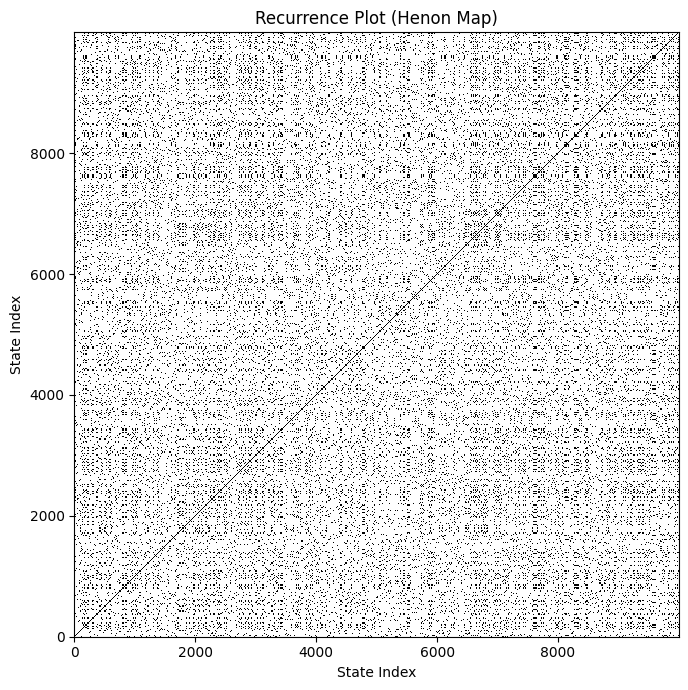

In [ ]:
# ==========================================================
# Generate Hénon time series
# ==========================================================

henon = simulate_henon(
    n_iterations=10000,
    transient_drop=1000
)

signal = henon[0]

# ==========================================================
# RQA parameters
# ==========================================================

d = 2
tau = 1
radius = 0.1

# ==========================================================
# Compute RQA metrics
# ==========================================================

result = run_webber1994(
    signal=signal,
    d=d,
    tau=tau,
    radius=radius
)

# ==========================================================
# Print RQA metrics
# ==========================================================

print("RQA Metrics")
print("-" * 30)
print(f"REC   : {result.REC:.4f} %")
print(f"DET   : {result.DET:.4f} %")
print(f"ENT   : {result.ENT:.4f} bits")
print(f"RATIO : {result.RATIO:.4f}")
print(f"TREND : {result.TREND:.4f}")

# ==========================================================
# Construct recurrence matrix for visualization
# ==========================================================

X = reconstruct_phase_space(signal, d, tau)
D = compute_distance_matrix(X)
R = compute_recurrence_matrix(D, radius)

# ==========================================================
# Plot recurrence matrix
# ==========================================================

plt.figure(figsize=(7, 7))
plt.imshow(
    R,
    cmap="binary",
    origin="lower",
    interpolation="nearest"
)

plt.title("Recurrence Plot (Henon Map)")
plt.xlabel("State Index")
plt.ylabel("State Index")
plt.tight_layout()
plt.show()

RQA Metrics
------------------------------
REC   : 2.8744 %
DET   : 29.9208 %
ENT   : 0.7571 bits
RATIO : 10.4096
TREND : 0.0074


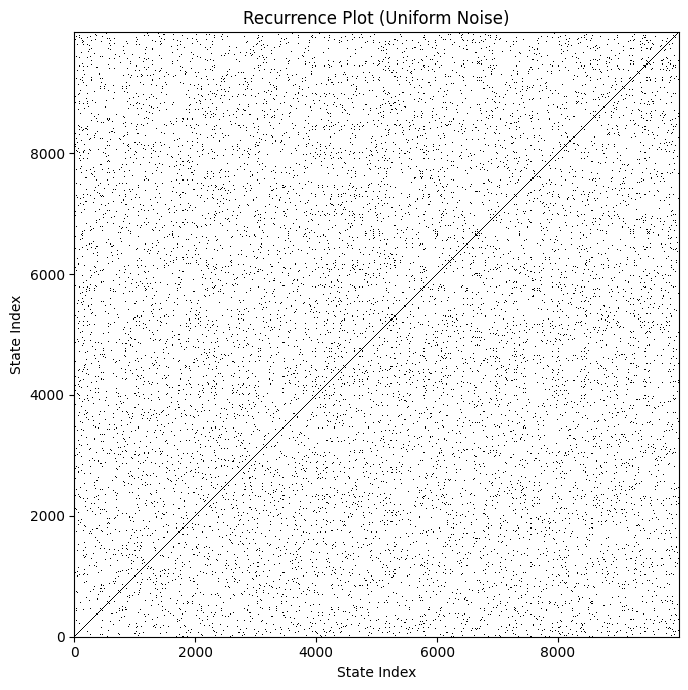

In [10]:
# ==========================================================
# Generate uniform random noise
# ==========================================================

signal = np.random.uniform(0.0, 1.0, 10000)

# ==========================================================
# RQA parameters
# ==========================================================

d = 2
tau = 1
radius = 0.1

# ==========================================================
# Compute RQA metrics
# ==========================================================

result = run_webber1994(
    signal=signal,
    d=d,
    tau=tau,
    radius=radius
)

# ==========================================================
# Print RQA metrics
# ==========================================================

print("RQA Metrics")
print("-" * 30)
print(f"REC   : {result.REC:.4f} %")
print(f"DET   : {result.DET:.4f} %")
print(f"ENT   : {result.ENT:.4f} bits")
print(f"RATIO : {result.RATIO:.4f}")
print(f"TREND : {result.TREND:.4f}")

# ==========================================================
# Construct recurrence matrix
# ==========================================================

X = reconstruct_phase_space(signal, d, tau)
D = compute_distance_matrix(X)
R = compute_recurrence_matrix(D, radius)

# ==========================================================
# Plot recurrence matrix
# ==========================================================

plt.figure(figsize=(7, 7))
plt.imshow(
    R,
    cmap="binary",
    origin="lower",
    interpolation="nearest"
)

plt.title("Recurrence Plot (Uniform Noise)")
plt.xlabel("State Index")
plt.ylabel("State Index")
plt.tight_layout()
plt.show()